# XGBoost Model Notebook: Recombination Only

In [1]:
# ============================================================
# GLOBAL CONFIGURATION
# Set GROUP before running. This controls input data, output
# paths, hyperparameters, and feature handling for all blocks.
# Valid values: "all", "I", "II", "III", "IV"
# ============================================================

from pathlib import Path

GROUP = "IV"

FEATURESETS_DIR = Path("../final_featuresets")

input_paths = {
    "All": FEATURESETS_DIR / "processedMaize_final.csv",
    "I":   FEATURESETS_DIR / "processedMaize_groupI_final.csv",
    "II":  FEATURESETS_DIR / "processedMaize_groupII_final.csv",
    "III": FEATURESETS_DIR / "processedMaize_groupIII_final.csv",
    "IV":  FEATURESETS_DIR / "processedMaize_groupIV_final.csv",
}

# Kept local and regenerable — not tracked in git (see .gitignore).
OUTPUT_DIR = Path("../maize_outputs/model_outputs_recomb_only")
PREFIX = f"group{GROUP}_recomb_only"

# # --- Location feature flag ---
# # 'location' is retained only for the "All" model.
# # For groups I-IV it is either redundant with the label (groups III, IV)
# # or dropped for cross-group consistency (groups I, II).
# USE_LOCATION = (GROUP == "All")

# --- Group Labels for Plot Titles ---
group_labels = {
    "All": "All Maize1/Maize2",
    "I":   "Group I",
    "II":  "Group II",
    "III": "Group III",
    "IV":  "Group IV"
}
GROUP_LABEL = group_labels[GROUP]

# --- Hyperparameters per group ---
hyperparams = {
    
    "All": dict(
        eval_metric="logloss",
        learning_rate=0.00113859,
        n_estimators=424,
        max_depth=9,
        subsample=0.83256662,
        colsample_bytree=0.53489384,
        min_child_weight=4,
        gamma=1.34201715,
        reg_alpha=3.62804934,
        reg_lambda=9.85234660,
        early_stopping_rounds=30,
    ),
    
    "I": dict(
        eval_metric="logloss",
        learning_rate=0.19960464,
        n_estimators=137,
        max_depth=12,
        subsample=0.98437098,
        colsample_bytree=0.58915264,
        min_child_weight=5,
        gamma=3.90770678,
        reg_alpha=2.56846895,
        reg_lambda=7.34208962,
        early_stopping_rounds=30,
    ),
    
    "II": dict(
        eval_metric="logloss",
        learning_rate=0.11698593,
        n_estimators=553,
        max_depth=8,
        subsample=0.97084876,
        colsample_bytree=0.70395721,
        min_child_weight=7,
        gamma=3.34449738,
        reg_alpha=2.32511857,
        reg_lambda=7.96432708,
        early_stopping_rounds=30,
    ),
    
    "III": dict(
        eval_metric="logloss",
        learning_rate=0.00241224,
        n_estimators=627,
        max_depth=6,
        subsample=0.62294385,
        colsample_bytree=0.60553667,
        min_child_weight=1,
        gamma=1.94158720,
        reg_alpha=2.74146148,
        reg_lambda=13.71351686,
        early_stopping_rounds=30,
    ),
    
    "IV": dict(
        eval_metric="logloss",
        learning_rate=0.23656269,
        n_estimators=804,
        max_depth=7,
        subsample=0.88794369,
        colsample_bytree=0.67638715,
        min_child_weight=1,
        gamma=3.46438509,
        reg_alpha=4.12439809,
        reg_lambda=13.35674966,
        early_stopping_rounds=30,
    ),
}

# --- Validate GROUP at startup ---
assert GROUP in input_paths, \
    f"Invalid GROUP '{GROUP}'. Must be one of: {list(input_paths.keys())}"

input_path = input_paths[GROUP]
params     = hyperparams[GROUP]

print(f"GROUP         : {GROUP}")
print(f"Input path    : {input_path}")
print(f"Output prefix : {PREFIX}")
print(f"Output dir    : {OUTPUT_DIR}")
# print(f"Use location  : {USE_LOCATION}")

GROUP         : IV
Input path    : /blue/meixiazhao/laylaaschuster/maizeGDM/final_maizeMLpreprocess/final_featuresets/processedMaize_groupIV_final.csv
Output prefix : groupIV_recomb_only
Output dir    : /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only


In [2]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, confusion_matrix,
    precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/blue/raquel.dias/laylaaschuster/conda/envs/maize_prom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# DATA LOADING AND PREPARATION
# ============================================================
def process_data():
    """
    Loads the feature matrix for the current GROUP and constructs
    a single-feature input matrix containing only recombination rate.
    This is a recombination-only ablation model: all other genomic
    and epigenomic features are excluded to isolate the predictive
    contribution of recombination rate alone.

    'location' is excluded from all models in this notebook, including
    the 'All' model, so that recombination rate is the sole input feature
    across all five model configurations.

    NaN values are intentionally retained in X:
      - tau:           NaN indicates FPKM = 0 across all tissues (biologically meaningful)
      - acr_Lup/Ldown: NaN indicates a chromosome-edge gene with no flanking sequence
    XGBoost handles NaN natively via its missing-value routing at each split.

    Returns
    -------
    my_data       : pd.DataFrame — full dataframe including all columns, for reference
    X             : np.ndarray   — feature matrix (recombination rate only)
    y             : np.ndarray   — 1D label vector (WGD column)
    feature_names : list         — ordered list of feature names corresponding to X columns
    """

    my_data = pd.read_csv(input_path)

    print(f"Loaded data shape: {my_data.shape}")
    print(f"Columns: {my_data.columns.tolist()}\n")

    # --- Validate expected columns are present in raw data ---
    assert "WGD" in my_data.columns, \
        "CRITICAL: 'WGD' column not found. Check input file."
    assert "recomb" in my_data.columns, \
        "CRITICAL: 'recomb' column not found. Check input file."

    # --- Define feature set: recombination rate only ---
    # All other features, including 'location', are excluded across all models.
    # Full data retained in my_data for traceability and downstream inspection.
    feature_names = ["recomb"]

    # --- Confirm feature set contains exactly the intended column ---
    assert feature_names == ["recomb"], \
        "CRITICAL: feature_names does not contain exactly ['recomb']. Check inclusion logic."
    assert "recomb" in my_data[feature_names].columns, \
        "CRITICAL: 'recomb' not found in feature matrix after selection. Check input file."

    print(f"Features used : {len(feature_names)}")
    print(f"Feature names : {feature_names}\n")

    # --- Extract feature matrix and label vector by name ---
    X = my_data[feature_names].to_numpy()
    y = my_data["WGD"].to_numpy()

    # --- Sanity checks ---
    assert X.shape[1] == 1, \
        f"CRITICAL: Feature matrix has {X.shape[1]} columns. Expected exactly 1 (recomb only)."
    assert X.shape[0] == y.shape[0], \
        f"CRITICAL: Row mismatch — X has {X.shape[0]} rows, y has {y.shape[0]}."
    assert set(np.unique(y)) == {0, 1}, \
        f"CRITICAL: Unexpected label values: {np.unique(y)}. Expected {{0, 1}}."

    unique_labels, counts = np.unique(y, return_counts=True)
    print("Label distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"  WGD={int(label)}: {count} samples")

    nan_report = my_data[feature_names].isna().sum()
    nan_report = nan_report[nan_report > 0]
    if len(nan_report) > 0:
        print("\nNaN values present in feature matrix (retained intentionally):")
        for col, n in nan_report.items():
            print(f"  {col}: {n} NaNs")
    else:
        print("\nNo NaN values in feature matrix.")

    return my_data, X, y, feature_names


my_data, X, y, feature_names = process_data()

Loaded data shape: (900, 61)
Columns: ['location', 'GC_genic', 'GC_prom', 'avg_expression', 'tau', 'Ka', 'Ks', 'O', 'acr_Lup', 'acr_Ldown', 'acr_S', 'recomb', 'CHH_up_avg', 'CHH_down_avg', 'CHH_body_avg', 'CHG_up_avg', 'CHG_down_avg', 'CHG_body_avg', 'CG_up_avg', 'CG_down_avg', 'CG_body_avg', 'CHH_up_max', 'CHH_down_max', 'CHG_up_max', 'CHG_down_max', 'CG_up_max', 'CG_down_max', 'TEdist', 'TEdenseAvgUp', 'TEdenseAvgDown', 'TEdenseMaxUp', 'TEdenseMaxDown', 'TE1', 'TE2', 'TE3', 'TE4', 'H2AZ_down', 'H3K4me1_down', 'H3K4me3_down', 'H3K9ac_down', 'H3K27ac_down', 'H3K27me3_down', 'H3K36me3_down', 'H3K56ac_down', 'H2AZ_genebody', 'H3K4me1_genebody', 'H3K4me3_genebody', 'H3K9ac_genebody', 'H3K27ac_genebody', 'H3K27me3_genebody', 'H3K36me3_genebody', 'H3K56ac_genebody', 'H2AZ_up', 'H3K4me1_up', 'H3K4me3_up', 'H3K9ac_up', 'H3K27ac_up', 'H3K27me3_up', 'H3K36me3_up', 'H3K56ac_up', 'WGD']

Features used : 1
Feature names : ['recomb']

Label distribution:
  WGD=0: 450 samples
  WGD=1: 450 samples

N

In [4]:
# ============================================================
# CELL 1: test_classifier() FUNCTION DEFINITION
# ============================================================

def test_classifier(X, y, feature_names):
    """
    Runs stratified 10-fold cross-validation with XGBoost.

    Early stopping uses a held-out validation split carved from
    the training fold only. The test fold is never involved in
    any training or stopping decision.

    NaN values in X are passed through untouched — XGBoost routes
    missing values natively at each split.

    Parameters
    ----------
    X            : np.ndarray — feature matrix, shape (n_samples, n_features)
    y            : np.ndarray — binary label vector, shape (n_samples,)
    feature_names: list       — feature names corresponding to columns of X

    Returns
    -------
    true_labels_all    : list  — true labels aggregated across all test folds
    predictions_all    : list  — predicted probabilities for WGD=1, all test folds
    fold_f1_scores     : list  — per-fold F1 score
    fold_train_losses  : list  — per-fold training log loss curve (list of lists)
    fold_val_losses    : list  — per-fold validation log loss curve (list of lists)
                                 Note: these are train/val curves, not train/test.
                                 The val set is carved from the training fold and
                                 is used solely to govern early stopping.
    shap_values_concat    : np.ndarray — SHAP values concatenated across test folds,
                                         shape (n_samples, n_features)
    X_tests_array         : np.ndarray — test fold feature matrices concatenated,
                                         shape (n_samples, n_features)
    shap_interaction_array: np.ndarray — Shapley interaction values concatenated
                                         across test folds,
                                         shape (n_samples, n_features, n_features).
                                         Entry [i, j, k] is the interaction index
                                         between features j and k for sample i.
                                         Diagonal [i, j, j] is feature j's main
                                         effect (contribution independent of other
                                         features) for sample i.
    """

    # --- Cross-validation setup ---
    # Stratified ensures class balance is maintained in every fold
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # --- Initialize tracking containers ---
    true_labels_all = []         # aggregated true labels across all test folds
    predictions_all = []         # aggregated predicted probabilities across all test folds
    fold_f1_scores  = []         # F1 score for each fold
    fold_auc_scores = []         # AUC score for each fold
    fold_train_losses = []       # training log loss curve per fold
    fold_val_losses   = []       # validation log loss curve per fold (used for early stopping)
    shap_values_list  = []       # SHAP values per fold, concatenated after loop
    # shap_interaction_list = [] # Shapley interaction values per fold, concatenated after loop
    X_tests = []                 # test fold arrays, concatenated after loop

    # --- Cross-validation loop ---
    for fold_index, (train_index, test_index) in enumerate(skf.split(X, y)):

        # Outer split: test fold is held out entirely
        X_train_full, X_test = X[train_index], X[test_index]
        y_train_full, y_test = y[train_index], y[test_index]

        # Inner split: carve a validation set from training data only.
        # This validation set governs early stopping and is never used
        # for metric reporting. test_size=0.1 gives ~10% of the training fold.
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=0.1,
            random_state=42,
            stratify=y_train_full  # maintain class balance in validation set
        )

        # Fresh classifier instance every fold — no state carried between folds
        classifier = xgb.XGBClassifier(**params)

        # Fit on training data.
        # eval_set: validation_0 = train, validation_1 = val (for early stopping).
        # X_test plays no role here.
        classifier.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )

        # --- Log loss curves ---
        results = classifier.evals_result()
        fold_train_losses.append(results['validation_0']['logloss'])
        fold_val_losses.append(results['validation_1']['logloss'])

        num_epochs = len(results['validation_0']['logloss'])
        print(f"Fold {fold_index + 1:>2}: {num_epochs} boosting rounds")

        # --- Predictions on held-out test fold ---
        # predict_proba uses best_iteration internally — not the final round
        y_pred_proba = classifier.predict_proba(X_test)[:, 1]
        y_pred_binary = (y_pred_proba > 0.5).astype(int)

        # Per-fold F1
        fold_f1 = f1_score(y_test, y_pred_binary)
        fold_f1_scores.append(fold_f1)
        print(f"         F1 = {fold_f1:.3f}")
        
        # Per-fold AUC
        fold_auc = roc_auc_score(y_test, y_pred_proba)
        fold_auc_scores.append(fold_auc)
        print(f"         AUC = {fold_auc:.3f}")

        # Aggregate labels and predictions for across-fold metrics
        true_labels_all.extend(y_test)
        predictions_all.extend(y_pred_proba)

        # Store test fold array for SHAP summary plots
        X_tests.append(X_test)

        # --- SHAP values for this fold ---
        # Explainer is built on X_train for this fold (background data).
        # SHAP values are computed on X_test — the held-out fold.
        # This ensures SHAP attribution reflects generalization, not training fit.
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test, check_additivity=True)
        shap_values_list.append(shap_values)
        
        # # --- True Shapley interaction values for this fold ---
        # # Evaluates the model over all feature subsets to measure how much
        # # the marginal contribution of feature j changes depending on the
        # # value of feature k, for each sample. 
        # # Output shape: (n_test_samples, n_features, n_features).
        # # Diagonal entry [i, j, j]: feature j's main effect for sample i
        # #   (contribution independent of interactions with other features).
        # # Off-diagonal entry [i, j, k]: interaction index between features
        # #   j and k for sample i. Positive = synergistic, negative = antagonistic.
        # # Note: shap_interaction_values() does not accept a check_additivity
        # # parameter — it always computes exactly. Do not add that argument.
        # shap_interact = explainer.shap_interaction_values(X_test)
        # shap_interaction_list.append(shap_interact)

    # --- Concatenate across folds ---
    # Every sample appears exactly once as a test sample across 10 folds
    X_tests_array      = np.concatenate(X_tests, axis=0)
    shap_values_concat = np.concatenate(shap_values_list, axis=0)
    # shap_interaction_array = np.concatenate(shap_interaction_list, axis=0)
    # shap_interaction_array shape: (n_total_samples, n_features, n_features)

    print(f"\nX_tests_array shape      : {X_tests_array.shape}")
    print(f"shap_values_concat shape   : {shap_values_concat.shape}")

    return (
        true_labels_all,
        predictions_all,
        fold_f1_scores,
        fold_auc_scores,
        fold_train_losses,
        fold_val_losses,
        shap_values_concat,
        X_tests_array,
        # shap_interaction_array
    )

In [5]:
# ============================================================
# CELL 2: RUN THE MODEL
# ============================================================

(
    true_labels_all,
    predictions_all,
    fold_f1_scores,
    fold_auc_scores,
    fold_train_losses,
    fold_val_losses,
    shap_values_array,
    X_test_array,
    # shap_interaction_array
) = test_classifier(X, y, feature_names)

Fold  1: 88 boosting rounds
         F1 = 0.790
         AUC = 0.952
Fold  2: 49 boosting rounds
         F1 = 0.878
         AUC = 0.927
Fold  3: 55 boosting rounds
         F1 = 0.863
         AUC = 0.957
Fold  4: 105 boosting rounds
         F1 = 0.787
         AUC = 0.908
Fold  5: 55 boosting rounds
         F1 = 0.860
         AUC = 0.939
Fold  6: 90 boosting rounds
         F1 = 0.857
         AUC = 0.953
Fold  7: 96 boosting rounds
         F1 = 0.843
         AUC = 0.940
Fold  8: 54 boosting rounds
         F1 = 0.819
         AUC = 0.931
Fold  9: 88 boosting rounds
         F1 = 0.795
         AUC = 0.901
Fold 10: 96 boosting rounds
         F1 = 0.786
         AUC = 0.900

X_tests_array shape      : (900, 1)
shap_values_concat shape   : (900, 1)


In [6]:
# ============================================================
# CELL 3: METRICS COMPUTATION
# ============================================================

# --- Convert predictions to binary labels at 0.5 threshold ---
y_true        = np.array(true_labels_all)
y_pred_probs  = np.array(predictions_all)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred_binary)
print("Confusion matrix:\n", cm)

# sklearn results — computed directly from labels and predictions
# zero_division=0 matches the custom function's divide-by-zero guard

precision_sk = precision_score(y_true, y_pred_binary, zero_division=0)
recall_sk    = recall_score(y_true, y_pred_binary, zero_division=0)
f1_pooled    = f1_score(y_true, y_pred_binary, zero_division=0)
accuracy_sk  = accuracy_score(y_true, y_pred_binary)

# --- Final reported metrics (sklearn) ---
print(f"\n--- Overall Metrics: Group {GROUP} ---")
print(f"Precision : {precision_sk:.4f}")
print(f"Recall    : {recall_sk:.4f}")
print(f"F1        : {f1_pooled:.4f}")
print(f"Accuracy  : {accuracy_sk:.4f}")

###### F1 summary ######

# --- Per-fold F1 summary ---
f1_mean = np.mean(fold_f1_scores)
f1_std  = np.std(fold_f1_scores)
print(f"\nPer-fold F1 — mean: {f1_mean:.4f}, std: {f1_std:.4f}")

f1_mean_df = pd.DataFrame({
    "model": [PREFIX],
    "f1_mean": [f1_mean],
    "f1_std": [f1_std],
    "f1_pooled": [f1_pooled],
})

results_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_f1_mean.csv")
f1_mean_df.to_csv(results_path, index=False)

# --- Per-fold F1 scores ---
fold_f1_df = pd.DataFrame({
    "fold":  list(range(1, len(fold_f1_scores) + 1)),
    "f1":    fold_f1_scores,
    "model": PREFIX
})
fold_f1_df.to_csv(os.path.join(OUTPUT_DIR, f"{PREFIX}_fold_f1.csv"), index=False)

# --- ROC curve data (for plotting in Cell C1) ---
fpr, tpr, _  = roc_curve(y_true, y_pred_probs)
roc_auc_pooled = auc(fpr, tpr)
print(f"\nROC AUC (pooled): {roc_auc_pooled:.4f}")

###### AUC summary ######

# --- Per-fold AUC summary ---
roc_auc_mean = np.mean(fold_auc_scores)
roc_auc_std  = np.std(fold_auc_scores)
print(f"Per-fold AUC — mean: {roc_auc_mean:.4f}, std: {roc_auc_std:.4f}")

auc_mean_df = pd.DataFrame({
    "model":          [PREFIX],
    "roc_auc_mean":   [roc_auc_mean],
    "roc_auc_std":    [roc_auc_std],
    "roc_auc_pooled": [roc_auc_pooled]
})
auc_mean_df.to_csv(os.path.join(OUTPUT_DIR, f"{PREFIX}_auc_mean.csv"), index=False)

# --- Per-fold AUC scores ---
fold_auc_df = pd.DataFrame({
    "fold":  list(range(1, len(fold_auc_scores) + 1)),
    "auc":   fold_auc_scores,
    "model": PREFIX
})
fold_auc_df.to_csv(os.path.join(OUTPUT_DIR, f"{PREFIX}_fold_auc.csv"), index=False)

# --- Sanity check: mean vs pooled comparison ---
print(f"\n--- Mean vs Pooled Sanity Check ---")
print(f"F1   — mean: {f1_mean:.4f}  pooled: {f1_pooled:.4f}  diff: {abs(f1_mean - f1_pooled):.4f}")
print(f"AUC  — mean: {roc_auc_mean:.4f}  pooled: {roc_auc_pooled:.4f}  diff: {abs(roc_auc_mean - roc_auc_pooled):.4f}")

Confusion matrix:
 [[395  55]
 [ 93 357]]

--- Overall Metrics: Group IV ---
Precision : 0.8665
Recall    : 0.7933
F1        : 0.8283
Accuracy  : 0.8356

Per-fold F1 — mean: 0.8279, std: 0.0346

ROC AUC (pooled): 0.9247
Per-fold AUC — mean: 0.9308, std: 0.0205

--- Mean vs Pooled Sanity Check ---
F1   — mean: 0.8279  pooled: 0.8283  diff: 0.0004
AUC  — mean: 0.9308  pooled: 0.9247  diff: 0.0062


Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only/groupIV_recomb_only_confusion_matrix.png


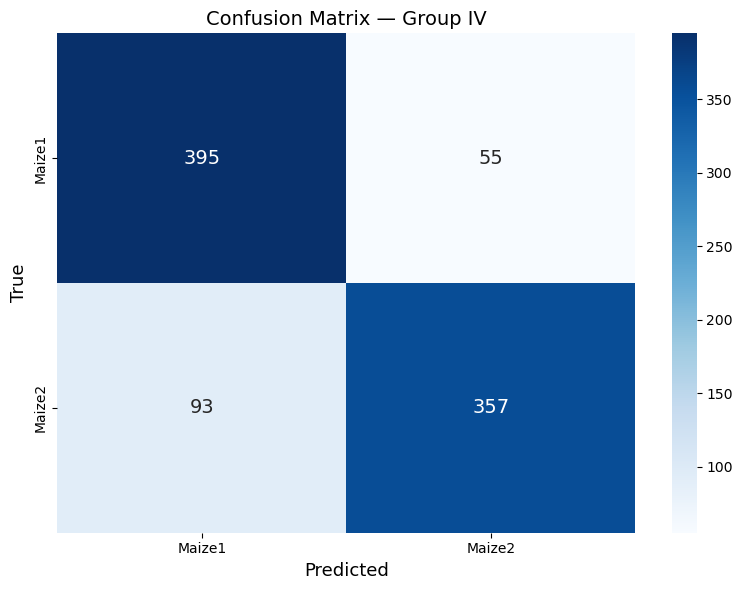

In [7]:
# ============================================================
# PLOT CELL A: CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Maize1", "Maize2"],
    yticklabels=["Maize1", "Maize2"],
    annot_kws={"size": 14},
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title(f"Confusion Matrix — {GROUP_LABEL}", fontsize=14)

plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_confusion_matrix.png")
plt.savefig(cm_path, bbox_inches='tight', dpi=600)
print(f"Saved: {cm_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only/groupIV_recomb_only_logloss_curves.png


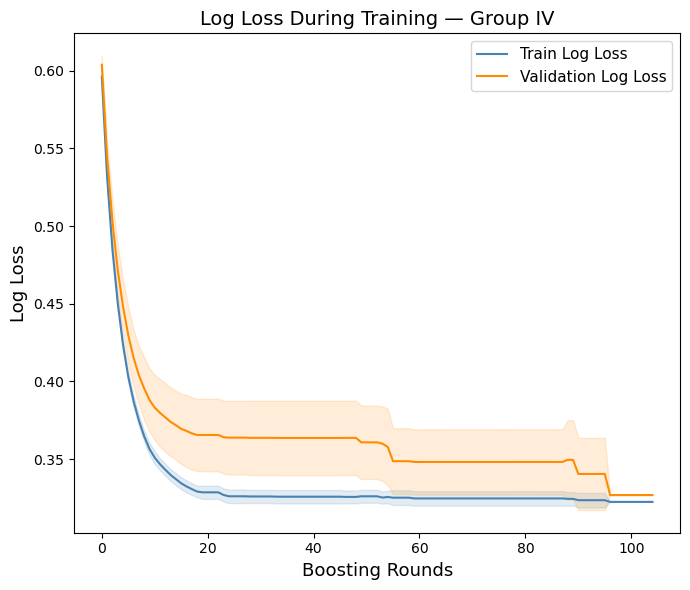

In [8]:
# ============================================================
# PLOT CELL B: LOG LOSS CURVES
# ============================================================
# Shows average training and validation log loss per boosting
# round, averaged across all 10 folds.
# Note: these are train/val curves — the validation set was
# carved from the training fold solely for early stopping.
# This is NOT train/test loss. See methods for distinction.
# ============================================================

# --- Pad loss curves to equal length across folds ---
# Different folds may stop at different boosting rounds due to
# early stopping, producing curves of unequal length.
# NaN-padding allows averaging across folds without bias.
max_epochs = max(len(loss) for loss in fold_train_losses)

padded_train = np.array([
    np.pad(loss, (0, max_epochs - len(loss)), constant_values=np.nan)
    for loss in fold_train_losses
])
padded_val = np.array([
    np.pad(loss, (0, max_epochs - len(loss)), constant_values=np.nan)
    for loss in fold_val_losses
])

# --- Average across folds, ignoring NaN padding ---
avg_train = np.nanmean(padded_train, axis=0)
avg_val   = np.nanmean(padded_val, axis=0)
std_train = np.nanstd(padded_train, axis=0)
std_val   = np.nanstd(padded_val, axis=0)

boosting_rounds = np.arange(max_epochs)

fig, ax = plt.subplots(figsize=(7, 6))

# Plot mean loss curves
ax.plot(boosting_rounds, avg_train, label="Train Log Loss",      color="steelblue")
ax.plot(boosting_rounds, avg_val,   label="Validation Log Loss", color="darkorange")

# Shaded bands show ± 1 std across folds
ax.fill_between(boosting_rounds,
                avg_train - std_train,
                avg_train + std_train,
                alpha=0.15, color="steelblue")
ax.fill_between(boosting_rounds,
                avg_val - std_val,
                avg_val + std_val,
                alpha=0.15, color="darkorange")

ax.set_title(f"Log Loss During Training — {GROUP_LABEL}", fontsize=14)
ax.set_xlabel("Boosting Rounds", fontsize=13)
ax.set_ylabel("Log Loss", fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()

logloss_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_logloss_curves.png")
plt.savefig(logloss_path, bbox_inches='tight', dpi=600)
print(f"Saved: {logloss_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only/groupIV_recomb_only_roc_data.csv
Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only/groupIV_recomb_only_roc_curve.png


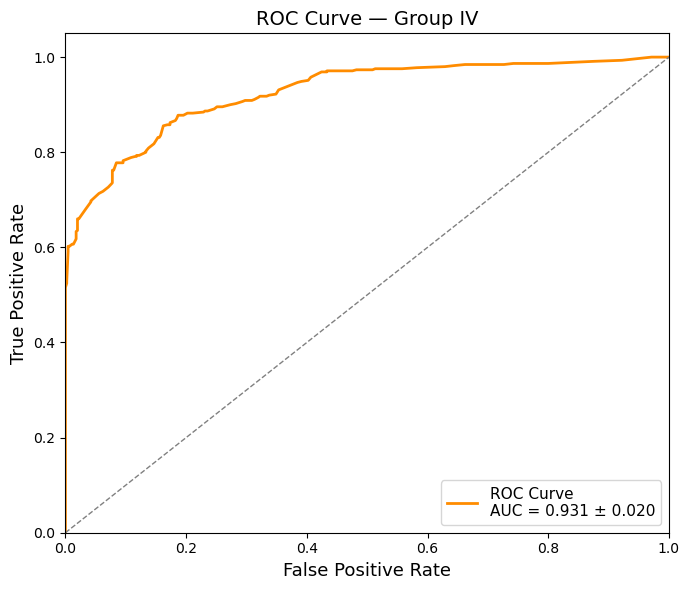

In [9]:
# ============================================================
# PLOT CELL C1: ROC CURVE
# ============================================================

roc_df = pd.DataFrame({
    "fpr":   fpr,
    "tpr":   tpr,
    "model": PREFIX,
    "auc":   roc_auc_pooled
})

roc_data_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_roc_data.csv")
roc_df.to_csv(roc_data_path, index=False)
print(f"Saved: {roc_data_path}")

# --- Predicted probabilities and true labels ---
probas_df = pd.DataFrame({
    "true_label": true_labels_all,
    "pred_proba": predictions_all,
    "model":      PREFIX
})
probas_df.to_csv(os.path.join(OUTPUT_DIR, f"{PREFIX}_predicted_probas.csv"), index=False)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve\nAUC = {roc_auc_mean:.3f} ± {roc_auc_std:.3f}"
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title(f"ROC Curve — {GROUP_LABEL}", fontsize=14)
ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()

roc_fig_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_roc_curve.png")
plt.savefig(roc_fig_path, bbox_inches='tight', dpi=600)
print(f"Saved: {roc_fig_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs_recomb_only/groupIV_recomb_only_f1_bar.png


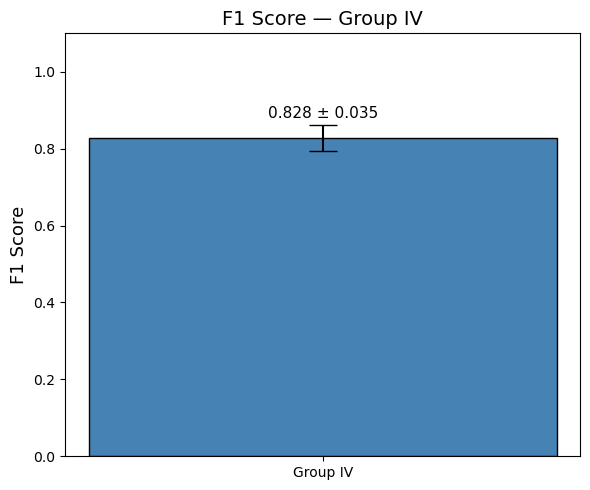

In [10]:
# ============================================================
# PLOT CELL C2: F1 BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    GROUP_LABEL,
    f1_mean,
    yerr=f1_std,
    capsize=10,
    color="steelblue",
    edgecolor="black",
    width=0.4
)

# Annotate bar with mean ± CV std
ax.text(
    0, f1_mean + f1_std + 0.01,
    f"{f1_mean:.3f} ± {f1_std:.3f}",
    ha="center", va="bottom", fontsize=11
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 Score", fontsize=13)
ax.set_title(f"F1 Score — {GROUP_LABEL}", fontsize=14)

plt.tight_layout()

f1_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_f1_bar.png")
plt.savefig(f1_path, bbox_inches='tight', dpi=600)
print(f"Saved: {f1_path}")

plt.show()
plt.close()

## SHAP Analysis

### SHAP Setup

In [ ]:
# ============================================================
# XAI CELL 1: SHAP SETUP — LABEL SPLIT, VALIDATION, SAVE
# ============================================================
# Reconstructs per-label SHAP arrays from cross-validation
# output. shap_values_array rows correspond to test-fold
# samples in the order they were collected across folds;
# true_labels_all contains the matching labels in that same
# order. These must be used together — do not substitute the
# full-dataset y from process_data() here.
# ============================================================

# --- Reconstruct label vector aligned to SHAP rows ---
y_shap = np.asarray(true_labels_all).ravel()
shap_vals = np.asarray(shap_values_array)

# --- Sanity checks ---
assert shap_vals.ndim == 2, \
    f"CRITICAL: shap_vals must be 2D, got shape {shap_vals.shape}"
assert shap_vals.shape[0] == y_shap.shape[0], \
    f"CRITICAL: Row mismatch — SHAP has {shap_vals.shape[0]} rows, " \
    f"labels have {y_shap.shape[0]}."
assert shap_vals.shape[1] == len(feature_names), \
    f"CRITICAL: Feature count mismatch — SHAP has {shap_vals.shape[1]} " \
    f"columns, feature_names has {len(feature_names)}."
assert set(np.unique(y_shap)) == {0, 1}, \
    f"CRITICAL: Unexpected label values in y_shap: {np.unique(y_shap)}"

print(f"SHAP array shape      : {shap_vals.shape}")
print(f"Label vector shape    : {y_shap.shape}")
print(f"WGD=0 (Maize1/dominant)  : {(y_shap == 0).sum()} samples")
print(f"WGD=1 (Maize2/submissive): {(y_shap == 1).sum()} samples")

# --- Split SHAP values by subgenome label ---
# shap_label0: SHAP values for WGD=0 genes (dominant subgenome, Maize1)
# shap_label1: SHAP values for WGD=1 genes (submissive subgenome, Maize2)
# Biological motivation: features driving dominant vs. submissive classification
# may be asymmetric — this is a core question in subgenome dominance research.
mask0 = (y_shap == 0)
mask1 = (y_shap == 1)

shap_label0 = shap_vals[mask0]
shap_label1 = shap_vals[mask1]

print(f"\nshap_label0 shape (Maize1): {shap_label0.shape}")
print(f"shap_label1 shape (Maize2): {shap_label1.shape}")

# --- Save per-label SHAP values as CSVs ---
shap_df_label0 = pd.DataFrame(shap_label0, columns=feature_names)
shap_df_label1 = pd.DataFrame(shap_label1, columns=feature_names)

path_label0_csv = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_label0.csv")
path_label1_csv = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_label1.csv")

shap_df_label0.to_csv(path_label0_csv, index=False)
shap_df_label1.to_csv(path_label1_csv, index=False)
print(f"\nSaved: {path_label0_csv}")
print(f"Saved: {path_label1_csv}")

# --- Save per-label SHAP values as compressed .npz ---
# Stores the full SHAP array alongside per-label splits, feature names,
# and per-label sample counts in one file for efficient downstream loading.
# shap_all: full test-fold SHAP array (all samples, both labels)
# shap_label0: SHAP values for WGD=0 samples (Maize1, dominant subgenome)
# shap_label1: SHAP values for WGD=1 samples (Maize2, submissive subgenome)
# This file is loaded by the networks notebook for heatmap and network analysis.
path_npz = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_by_label.npz")

# --- Validate interaction array before save ---
# shap_interaction_array is returned from test_classifier() and unpacked
# in Cell 2. Validated here alongside the 2D SHAP array for consistency.
assert shap_interaction_array.ndim == 3, (
    f"CRITICAL: shap_interaction_array must be 3D, "
    f"got {shap_interaction_array.ndim}D."
)
assert shap_interaction_array.shape[0] == shap_vals.shape[0], (
    f"CRITICAL: Interaction array sample count "
    f"({shap_interaction_array.shape[0]}) does not match "
    f"SHAP array ({shap_vals.shape[0]})."
)
assert shap_interaction_array.shape[1] == shap_interaction_array.shape[2], (
    "CRITICAL: Interaction array feature dimensions are not square."
)
assert shap_interaction_array.shape[1] == len(feature_names), (
    f"CRITICAL: Interaction array feature dim "
    f"({shap_interaction_array.shape[1]}) does not match "
    f"feature_names ({len(feature_names)})."
)
print(f"shap_interaction_array shape  : {shap_interaction_array.shape}")

np.savez_compressed(
    path_npz,
    shap_all             = shap_vals.astype(np.float32),
    shap_label0          = shap_label0.astype(np.float32),
    shap_label1          = shap_label1.astype(np.float32),
    shap_interaction_all = shap_interaction_array.astype(np.float32),
    true_labels          = y_shap.astype(np.int8),
    feature_names        = np.asarray(feature_names),
    counts               = np.array([mask0.sum(), mask1.sum()])
)
print(f"Saved: {path_npz}")

### Feature Definitions

In [ ]:
# ============================================================
# XAI CELL 2: FEATURE DEFINITIONS — RENAME DICT, GROUPS, COLORS
# ============================================================
# All downstream XAI cells reference these dictionaries.
# Do not redefine feature_rename_dict, feature_groups,
# feature_to_group, group_to_color, or renamed_feature_names
# anywhere else in this notebook.
#
# Feature names reflect the updated preprocessing output.
# See preprocessing script for full column provenance.
# ============================================================

# --- Short display names for all features ---
# Used on all XAI plots for consistency and readability.
# Keys are exact column names from preprocessing output.
feature_rename_dict = {
    'location':             'Loc',
    'GC_genic':             'GCd',
    'GC_prom':              'GCp',
    'avg_expression':       'Exp',
    'tau':                  '\u03C4',    # Greek tau — tissue specificity index
    'Ka':                   'Ka',
    'Ks':                   'Ks',
    'O':                    '\u03C9',    # Greek omega (Ka/Ks ratio)
    'acr_Lup':              'ACRdu',
    'acr_Ldown':            'ACRdd',
    'acr_S':                'ACRs',
    'recomb':               'Re',
    'CHH_up_avg':           'M1',
    'CHH_down_avg':         'M2',
    'CHH_body_avg':         'M3',
    'CHG_up_avg':           'M4',
    'CHG_down_avg':         'M5',
    'CHG_body_avg':         'M6',
    'CG_up_avg':            'M7',
    'CG_down_avg':          'M8',
    'CG_body_avg':          'M9',
    'CHH_up_max':           'M10',
    'CHH_down_max':         'M11',
    'CHG_up_max':           'M12',
    'CHG_down_max':         'M13',
    'CG_up_max':            'M14',
    'CG_down_max':          'M15',
    'TEdist':               'TEdi',
    'TEdenseAvgUp':         'TEu1',
    'TEdenseAvgDown':       'TEd1',
    'TEdenseMaxUp':         'TEu2',
    'TEdenseMaxDown':       'TEd2',
    'TE1':                  'TE1',
    'TE2':                  'TE2',
    'TE3':                  'TE3',
    'TE4':                  'TE4',
    'H2AZ_down':            'Hd1',
    'H3K4me1_down':         'Hd2',
    'H3K4me3_down':         'Hd3',
    'H3K9ac_down':          'Hd4',
    'H3K27ac_down':         'Hd5',
    'H3K27me3_down':        'Hd6',
    'H3K36me3_down':        'Hd7',
    'H3K56ac_down':         'Hd8',
    'H2AZ_genebody':        'Hg1',
    'H3K4me1_genebody':     'Hg2',
    'H3K4me3_genebody':     'Hg3',
    'H3K9ac_genebody':      'Hg4',
    'H3K27ac_genebody':     'Hg5',
    'H3K27me3_genebody':    'Hg6',
    'H3K36me3_genebody':    'Hg7',
    'H3K56ac_genebody':     'Hg8',
    'H2AZ_up':              'Hu1',
    'H3K4me1_up':           'Hu2',
    'H3K4me3_up':           'Hu3',
    'H3K9ac_up':            'Hu4',
    'H3K27ac_up':           'Hu5',
    'H3K27me3_up':          'Hu6',
    'H3K36me3_up':          'Hu7',
    'H3K56ac_up':           'Hu8',
}

# --- Feature group membership ---
# Used for color-coding in bar charts and network node coloring.
# 'location' is included here for color assignment purposes but
# will only appear in plots when USE_LOCATION=True (GROUP="all").
# Features absent from the active feature_names are ignored silently.
feature_groups = {
    'ACR': [
        'acr_Lup', 'acr_Ldown', 'acr_S',
    ],
    'Methylation': [
        'CHH_up_avg', 'CHH_down_avg', 'CHH_body_avg',
        'CHG_up_avg', 'CHG_down_avg', 'CHG_body_avg',
        'CG_up_avg',  'CG_down_avg',  'CG_body_avg',
        'CHH_up_max', 'CHH_down_max',
        'CHG_up_max', 'CHG_down_max',
        'CG_up_max',  'CG_down_max',
    ],
    'TE': [
        'TEdenseAvgUp', 'TEdenseAvgDown',
        'TEdenseMaxUp', 'TEdenseMaxDown',
        'TE1', 'TE2', 'TE3', 'TE4',
        'TEdist',
    ],
    'Histone Modifications Downstream': [
        'H2AZ_down',     'H3K4me1_down',  'H3K4me3_down',  'H3K9ac_down',
        'H3K27ac_down',  'H3K27me3_down', 'H3K36me3_down', 'H3K56ac_down',
    ],
    'Histone Modifications Genebody': [
        'H2AZ_genebody',     'H3K4me1_genebody',  'H3K4me3_genebody',  'H3K9ac_genebody',
        'H3K27ac_genebody',  'H3K27me3_genebody', 'H3K36me3_genebody', 'H3K56ac_genebody',
    ],
    'Histone Modifications Upstream': [
        'H2AZ_up',     'H3K4me1_up',  'H3K4me3_up',  'H3K9ac_up',
        'H3K27ac_up',  'H3K27me3_up', 'H3K36me3_up', 'H3K56ac_up',
    ],
    'Recombination':       ['recomb'],
    'Evolutionary Pressure': ['Ka', 'Ks', 'O'],
    'Location':            ['location'],
    'GC Content':          ['GC_genic', 'GC_prom'],
    'Expression':          ['avg_expression', 'tau'],
}

# --- Derived lookups (do not edit below this line) ---

# Maps each feature name to its group label
feature_to_group = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

# Assigns one color per group — consistent across all XAI plots
_n_groups    = len(feature_groups)
_group_cmap  = plt.colormaps['tab20b'](np.linspace(0, 1, _n_groups))
group_to_color = {
    group: color
    for group, color in zip(feature_groups.keys(), _group_cmap)
}

# Short display names for the active feature set, in column order
# Derived from the live feature_names list — never hardcoded
renamed_feature_names = [
    feature_rename_dict.get(f, f) for f in feature_names
]

# --- Validation: warn if any active feature is missing from rename dict ---
missing = [f for f in feature_names if f not in feature_rename_dict]
if missing:
    print(f"WARNING: {len(missing)} feature(s) not in feature_rename_dict "
          f"— will display raw column name on plots:")
    for f in missing:
        print(f"  {f}")
else:
    print(f"Feature rename dict validated: all {len(feature_names)} "
          f"active features have short names.")

# --- Summary ---
print(f"\nActive features     : {len(feature_names)}")
print(f"Groups defined      : {len(feature_groups)}")
print(f"USE_LOCATION        : {USE_LOCATION}")
if not USE_LOCATION:
    print("  → 'location' / 'Loc' will not appear in this model's plots")

### Feature Importance Proportion

In [ ]:
# ============================================================
# XAI CELL 3: FEATURE IMPORTANCE PROPORTION
# ============================================================
# Computes each feature's share of total absolute SHAP
# importance, expressed as a percentage. This is a normalized
# summary of mean absolute SHAP magnitude across all test-fold
# samples. It does not distinguish direction (positive vs.
# negative SHAP) — use the summary dot plots for that.
#
# Uses shap_vals (all samples, both labels) from XAI Cell 1.
# ============================================================

# --- Sum of absolute SHAP values across all samples per feature ---
# Shape: (n_features,)
# Each entry is the total absolute SHAP contribution of that
# feature summed across every test-fold sample.
shap_abs_sum     = np.sum(np.abs(shap_vals), axis=0)
total_shap_value = np.sum(shap_abs_sum)

assert shap_abs_sum.shape[0] == len(feature_names), \
    "CRITICAL: shap_abs_sum length does not match feature_names."
assert total_shap_value > 0, \
    "CRITICAL: Total absolute SHAP value is zero — check shap_vals."

# --- Compute percentage contribution per feature ---
feature_proportions = (shap_abs_sum / total_shap_value) * 100

# --- Build summary DataFrame ---
importance_df = pd.DataFrame({
    'feature':      feature_names,
    'short_name':   renamed_feature_names,
    'abs_shap_sum': shap_abs_sum,
    'pct_total':    feature_proportions.round(2),
}).sort_values(by='pct_total', ascending=False).reset_index(drop=True)

# --- Print top 10 for quick inspection ---
print(f"Total absolute SHAP value: {total_shap_value:.4f}")
print(f"\nTop 10 features by SHAP importance proportion ({GROUP_LABEL}):")
print(importance_df[['short_name', 'pct_total']].head(10).to_string(index=False))

# --- Save full table ---
importance_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_importance_proportion.csv")
importance_df.to_csv(importance_path, index=False)
print(f"\nSaved: {importance_path}")

# --- Display full table in notebook ---
display(importance_df)

### Aggregate SHAP Summary Plot (Beeswarm)

In [ ]:
# ============================================================
# XAI CELL 4: SHAP SUMMARY PLOT — ALL SAMPLES (BEESWARM)
# ============================================================
# Beeswarm plot of SHAP values across all test-fold samples.
# Each row is a feature (ranked by mean absolute SHAP, high
# to low). Each dot is one sample; color encodes feature value
# (red = high, blue = low). Horizontal position encodes the
# SHAP value (impact on model output).
#
# This plot reflects classification of both WGD=0 (Maize1,
# dominant) and WGD=1 (Maize2, submissive) samples together.
# Per-label beeswarm plots are in XAI Cell 5.
#
# Note: shap.summary_plot() is called with a raw numpy array.
# The array interface defaults to the beeswarm plot type and
# does not accept an explicit plot_type argument — that
# argument is only supported via the Explanation object API.
# ============================================================

fig_summary_all = plt.figure()

shap.summary_plot(
    shap_vals,
    X_test_array,
    feature_names  = renamed_feature_names,
    max_display    = len(feature_names),
    show           = False,
)

plt.title(f"SHAP Summary — {GROUP_LABEL}", fontsize=14)
plt.tight_layout()

summary_all_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_summary_all.png")
plt.savefig(summary_all_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_all_path}")

plt.show()
plt.close()

### Per-Label SHAP Summary Plot (Side-by-Side Beeswarm Panel)

In [ ]:
# ============================================================
# XAI CELL 5: SHAP SUMMARY PLOT — PER LABEL (BEESWARM)
# ============================================================
# Separate beeswarm plots for WGD=0 (Maize1, dominant
# subgenome) and WGD=1 (Maize2, submissive subgenome).
#
# Within each plot, features are ranked independently by
# mean absolute SHAP for that label's samples. Differences
# in rank order between plots reflect asymmetry in which
# features drive dominant vs. submissive classification —
# a core question in subgenome dominance research.
#
# Gray dots indicate NaN feature values (biologically
# meaningful for tau, acr_Lup, acr_Ldown — see Cell 1).
#
# X_test_label0/1 are the feature matrices for the same
# samples as shap_label0/1, extracted using the masks
# defined in XAI Cell 1.
# ============================================================

# --- Slice X_test_array to match per-label SHAP arrays ---
X_test_label0 = X_test_array[mask0]
X_test_label1 = X_test_array[mask1]

assert X_test_label0.shape[0] == shap_label0.shape[0], \
    "CRITICAL: X_test_label0 row count does not match shap_label0."
assert X_test_label1.shape[0] == shap_label1.shape[0], \
    "CRITICAL: X_test_label1 row count does not match shap_label1."

# --- WGD=0: Maize1 dominant subgenome ---
shap.summary_plot(
    shap_label0,
    X_test_label0,
    feature_names = renamed_feature_names,
    max_display   = len(feature_names),
    show          = False,
)
plt.title(f"WGD=0  Maize1 (dominant) — {GROUP_LABEL}", fontsize=13)
plt.tight_layout()

summary_label0_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_summary_label0.png")
plt.savefig(summary_label0_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_label0_path}")
plt.show()
plt.close()

# --- WGD=1: Maize2 submissive subgenome ---
shap.summary_plot(
    shap_label1,
    X_test_label1,
    feature_names = renamed_feature_names,
    max_display   = len(feature_names),
    show          = False,
)
plt.title(f"WGD=1  Maize2 (submissive) — {GROUP_LABEL}", fontsize=13)
plt.tight_layout()

summary_label1_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_summary_label1.png")
plt.savefig(summary_label1_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_label1_path}")
plt.show()
plt.close()

### Color-coded SHAP Bar Chart

In [ ]:
# ============================================================
# XAI CELL 6: COLOR-CODED SHAP BAR CHART (SUPPLEMENTAL)
# ============================================================
# Horizontal bar chart showing the sum of positive (blue) and
# negative (red) SHAP values per feature across all test-fold
# samples, sorted by total absolute SHAP magnitude (ascending,
# so highest-importance features appear at the top).
#
# Note: values are SUMMED across samples, not meaned. This
# reflects total directional contribution across the test set.
# For per-sample magnitude ranking, see the beeswarm plots
# (XAI Cells 4 and 5) and importance proportion (XAI Cell 3).
#
# Colored tiles on the left margin indicate feature group
# membership, consistent with network node colors (Cell 2).
# feature_rename_dict, feature_to_group, and group_to_color
# are defined in XAI Cell 2 — not redefined here.
# ============================================================

# --- Compute summed positive and negative SHAP per feature ---
# Use local array variable to avoid overwriting global feature_names list
positive_shap_values = np.sum(shap_vals * (shap_vals > 0), axis=0)
negative_shap_values = np.sum(shap_vals * (shap_vals < 0), axis=0)
absolute_shap_values = np.abs(positive_shap_values) + np.abs(negative_shap_values)

# --- Sort by total absolute SHAP (ascending — highest at top of plot) ---
sorted_indices = np.argsort(absolute_shap_values)

feature_names_arr = np.array(feature_names)

# Short names in the same sorted order
feature_names_sorted = feature_names_arr[sorted_indices]
positive_shap_values_sorted = positive_shap_values[sorted_indices]
negative_shap_values_sorted = negative_shap_values[sorted_indices]

# --- Build figure ---
fig, ax = plt.subplots(figsize=(10, 14))

y_positions = np.arange(len(feature_names_sorted))
bars = ax.barh(y_positions, positive_shap_values_sorted, color='b')
ax.barh(y_positions, negative_shap_values_sorted, color='r')

# --- Group color tile axis (left margin) ---
ax2 = fig.add_axes([0.002, 0.1, 0.05, 0.8])
ax2.set_ylim(ax.get_ylim())
ax2.set_xlim(0, 1)
ax2.axis('off')

for i, feature in enumerate(feature_names_sorted):
    group = feature_to_group.get(feature, 'Other')
    color = group_to_color.get(group, 'gray')
    ax2.add_patch(mpatches.Rectangle((0, y_positions[i]), 1, 0.8, color=color))
    
# --- Axis formatting ---
ax.set_xlabel('Sum of SHAP Values', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.yaxis.set_label_coords(-0.18, 0.5)
ax.set_title(f"SHAP Values — {GROUP_LABEL}")
ax.set_ylim(-3.2, len(feature_names_sorted) + 0.5)

feature_rename_sorted = [feature_rename_dict.get(f, f) for f in feature_names_sorted]
ax.set_yticks(y_positions)
ax.set_yticklabels(feature_rename_sorted, fontsize=12)
ax.grid(True, axis='y')

# --- Group color legend ---
legend_patches = [
    mpatches.Patch(color=color, label=group) 
    for group, color in group_to_color.items()
]
ax.legend(handles=legend_patches, title="Feature Groups", bbox_to_anchor=(0.43, 0.15), loc='right')

bar_chart_path = os.path.join(OUTPUT_DIR, f"{PREFIX}_shap_bar_chart.png")
plt.savefig(bar_chart_path, bbox_inches='tight', dpi=600)
print(f"Saved: {bar_chart_path}")

plt.show()
plt.close()